In [1]:
import json
import pickle
import logging
import os
import warnings

import joblib
import mlflow
import numpy as np
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, 
                             ConfusionMatrixDisplay, precision_recall_fscore_support, 
                             precision_score, recall_score, roc_auc_score)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split, cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)
warnings.filterwarnings("ignore")

/Users/brian02oriel/Documents/Python projects/platzi-ml-courses/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def read_csv(file_name: str, path="data/data_processed/") -> pd.DataFrame:
    """
    Read csv file
    :param file_name: file name
    :param path: path to the file
    :return: pandas dataframe
    """
    return pd.read_csv(os.path.join(path, file_name))

In [3]:
df_tickets = read_csv("tickets_inputs_eng_1.csv")

In [4]:
df_tickets.shape

(18961, 4)

In [5]:
df_tickets.sample(5)

,complaint_what_happened,ticket_classification,processed_text,relevant_topics
240,There was a hard inquiry on my account that I ...,"Credit reporting, credit repair services, or o...",inquiri account appli,Mortgage/Loan
8343,I made an electronic deposit to my Chase check...,Checking or savings account + Checking account,deposit chase check account amount post accoun...,Mortgage/Loan
12019,On XX/XX/XXXX I attempted to buy tickets from ...,Checking or savings account + Checking account,attempt ticket somebodi chase bank offer spli...,Bank Account Services
3207,XX/XX/XXXX Paid merchant for repair of equipme...,Credit card or prepaid card + General-purpose ...,merchant repair advis merchant repair fault s...,Bank Account Services
47,I am XXXX military member ( XXXX ) with the XX...,Consumer Loan + Vehicle loan,militari member auto financ refus pay gap ins...,Mortgage/Loan


In [6]:
df_tickets.relevant_topics.value_counts()

relevant_topics
Mortgage/Loan                    16376
Bank Account Services             2358
Credit Report or Prepaid Card      227
Name: count, dtype: int64

In [7]:
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("tickets_baseline")

skops_trusted_types=['sklearn.metrics._classification.f1_score', 'sklearn.metrics._scorer._Scorer', 'sklearn.model_selection._split.StratifiedKFold']


def data_transform(df: pd.DataFrame):
    """This function transform the data into X and y
    Args:
      df (pd.DataFrame): dataframe with the data
    Returns:
      X (pd.Series): series with the text
      y (pd.Series): series with the labels"""
    X = df["processed_text"]
    y = df["relevant_topics"]

    return X, y


def read_idx2label(json_path: str) -> pd.Series:
    """This function read the json file and return a dictionary
    Args:
      json_path (str): path to the json file
     Returns:
      idx2label (dict): dictionary with the mapping"""
    with open(json_path) as f:
        idx2label = json.load(f)
    return idx2label


def decode_labels_into_idx(labels: pd.Series, idx2label: dict) -> pd.Series:
    """This function decode the labels into idx
    Args:
      labels (pd.Series): series with the labels
      idx2label (dict): dictionary with the mapping
     Returns:
      labels (pd.Series): series with the labels decoded
    """
    return labels.map(idx2label)


def fit_transform(X: pd.Series) -> np.ndarray:
    count_vectorizer = CountVectorizer()
    X_vectorized = count_vectorizer.fit_transform(X)
    #save count vectorizer for data preprocessing in the main app (deploy)
    joblib.dump(count_vectorizer, 'data/data_processed/count_vectorizer.pkl')
    logger.info("count vectorizer trained successfully stored")
    return X_vectorized


def transform_tfidf(X_vectorized: object) -> np.ndarray:
    tfidf_transformer = TfidfTransformer()
    X_tfidf = tfidf_transformer.fit_transform(X_vectorized)
    joblib.dump(X_tfidf, 'data/data_processed/X_tfidf.pkl')
    logger.info("X_tfidf trained successfully stored")
    return X_tfidf

def save_pickle(data, filename) -> None:
    """
    This function saves the data in a pickle file
    Args:
        data (object): data to save
        filename (str): filename
    Returns:
        None
    """
    filepath = os.path.join("data", "data_processed", f"{filename}.pkl")
    with open(filepath, 'wb') as file:
        pickle.dump(data, file)

def split_train_test(
    X_tfidf: np.array, y: pd.Series, test_size: float = 0.3, random_state: int = 42
) -> tuple:
    """
    This function splits the data into train and test
    Args:
      X_tfidf (np.array): array with the vectorized data
      y (pd.Series): series with the labels
      test_size (float): test size
      random_state (int): random state
    Returns:
      X_train (np.array): array with the vectorized data for train
      X_test (np.array): array with the vectorized data for test
      y_train (pd.Series): series with the labels for train
      y_test (pd.Series): series with the labels for test
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X_tfidf, y, test_size=test_size, random_state=random_state
    )
    save_pickle((X_train, y_train), "train")
    save_pickle((X_test, y_test),  "test")
    logger.info("data saved successfully in pickle files")
    return X_train, X_test, y_train, y_test

def display_classification_report(
    model: object,
    name_model: str,
    developer: str,
    X_train: np.array,
    X_test: np.array,
    y_train: np.array,
    y_test: np.array,
    use_cv = False
):
    """This function display the classification report
    Args:
      model (object): model
      name_model (str): name of the model
      developer (str): developer name
      X_train (np.array): array with the vectorized data for train
      X_test (np.array): array with the vectorized data for test
      y_train (pd.Series): series with the labels for train
      y_test (pd.Series): series with the labels for test
     Returns:
      metric (list): list with the metrics"""
    
    print("------------------- NAME MODEL ------------------- | ", name_model)
    # star experiment in mlflow
    with mlflow.start_run(run_name=name_model):
        mlflow.log_param("model", name_model)
        mlflow.log_param("developer", developer)
        # empty list to store the metrics and then tracking them in mlflow
        metric = []
        y_train_pred_proba = model.predict_proba(X_train)
        y_test_pred_proba = model.predict_proba(X_test)
        roc_auc_score_train = round(
            roc_auc_score(
                y_train, y_train_pred_proba, average="weighted", multi_class="ovr"
            ),
            2,
        )
        roc_auc_score_test = round(
            roc_auc_score(
                y_test, y_test_pred_proba, average="weighted", multi_class="ovr"
            ),
            2,
        )

        logger.info("ROC AUC Score Train:", roc_auc_score_train)
        logger.info("ROC AUC Score Test:", roc_auc_score_test)
        
        # adding the metrics to the list
        metric.extend([roc_auc_score_train, roc_auc_score_test])

        mlflow.log_metric("roc_auc_train", roc_auc_score_train)
        mlflow.log_metric("roc_auc_test", roc_auc_score_test)

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        (
            precision_train,
            recall_train,
            fscore_train,
            support_train,
        ) = precision_recall_fscore_support(y_train, y_train_pred, average="weighted")
        (
            precision_test,
            recall_test,
            fscore_test,
            support_test,
        ) = precision_recall_fscore_support(y_test, y_test_pred, average="weighted")

        mlflow.log_metric("precision_train", precision_train)
        mlflow.log_metric("precision_test", precision_test)
        mlflow.log_metric("recall_train", recall_train)
        mlflow.log_metric("recall_test", recall_test)
        
        try:
            if use_cv:
                best_params = model.best_params_
            else:
                best_params = model.get_params()
            mlflow.log_params(best_params)

        except AttributeError as e:
            logger.info(f"Error: {e}")

        mlflow.sklearn.log_model(model, f"model_{name_model}", skops_trusted_types=skops_trusted_types)

        acc_score_train = round(accuracy_score(y_train, y_train_pred), 2)
        acc_score_test = round(accuracy_score(y_test, y_test_pred), 2)

        metric.extend(
            [
                acc_score_train,
                acc_score_test,
                round(precision_train, 2),
                round(precision_test, 2),
                round(recall_train, 2),
                round(recall_test, 2),
                round(fscore_train, 2),
                round(fscore_test, 2),
            ]
        )

        print("Train Accuracy: ", acc_score_train)
        print("Test Accuracy: ", acc_score_test)

        model_report_train = classification_report(y_train, y_train_pred)
        model_report_test = classification_report(y_test, y_test_pred)

        print("Classification Report for Train:\n", model_report_train)
        print("Classification Report for Test:\n", model_report_test)

        # Plot the confusion matrix
        fig, ax = plt.subplots(figsize=(12, 8))

        # Create the confusion matrix with labels decoded
        decoded_y_test_pred = [idx2label[idx] for idx in y_test_pred]
        decoded_y_test = [idx2label[idx] for idx in y_test]

        cm = confusion_matrix(decoded_y_test, decoded_y_test_pred)
        cmp = ConfusionMatrixDisplay(cm, display_labels=list(idx2label.values()))
        cmp.plot(ax=ax)

        plt.xticks(rotation=80)
        plt.show()

        mlflow.sklearn.log_model(model, name_model, skops_trusted_types=skops_trusted_types)

        return metric


def grid_search(model, folds, params, scoring):
    """This function perform a grid search
    Args:
        model (object): model
        folds (int): number of folds
        params (dict): dictionary with the parameters
        scoring (str): scoring
    Returns:
        grid_search (object): grid search
    """

    grid_search = GridSearchCV(
        model, cv=folds, param_grid=params, scoring=scoring, n_jobs=-1, verbose=1
    )
    return grid_search


def print_best_score_params(model):
    """This functions print best score and best hyperparameters for baselines models
    Args:
        model (object): model
    Returns:
        None"""
    print("Best Score: ", model.best_score_)
    print("Best Hyperparameters: ", model.best_params_)

In [8]:
idx2label = read_idx2label(json_path="data/data_processed/topic_mapping_1.json")
label2idx = {value: key for key, value in idx2label.items()}

X, y = data_transform(df_tickets)
y = decode_labels_into_idx(labels=y, idx2label=label2idx)

X_vectorized = fit_transform(X.values)
X_tfidf = transform_tfidf(X_vectorized)
X_train, X_test, y_train, y_test = split_train_test(X_tfidf, y)

INFO:__main__:count vectorizer trained successfully stored
INFO:__main__:X_tfidf trained successfully stored
INFO:__main__:data saved successfully in pickle files


--- Logging error ---
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/logging/__init__.py", line 1160, in emit
    msg = self.format(record)
          ^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/logging/__init__.py", line 999, in format
    return fmt.format(record)
           ^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/logging/__init__.py", line 703, in format
    record.message = record.getMessage()
                     ^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/logging/__init__.py", line 392, in getMessage
    msg = msg % self.args
          ~~~~^~~~~~~~~~~
TypeError: not all arguments converted during string formatting
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/brian02oriel/Documents/Pyt

------------------- NAME MODEL ------------------- |  MultinomialNB


2026/06/28 13:23:33 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Train Accuracy:  0.86
Test Accuracy:  0.86
Classification Report for Train:
               precision    recall  f1-score   support

           0       0.25      0.00      0.00      1653
           1       0.00      0.00      0.00       148
           2       0.86      1.00      0.93     11471

    accuracy                           0.86     13272
   macro avg       0.37      0.33      0.31     13272
weighted avg       0.78      0.86      0.80     13272

Classification Report for Test:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       705
           1       0.00      0.00      0.00        79
           2       0.86      1.00      0.93      4905

    accuracy                           0.86      5689
   macro avg       0.29      0.33      0.31      5689
weighted avg       0.74      0.86      0.80      5689



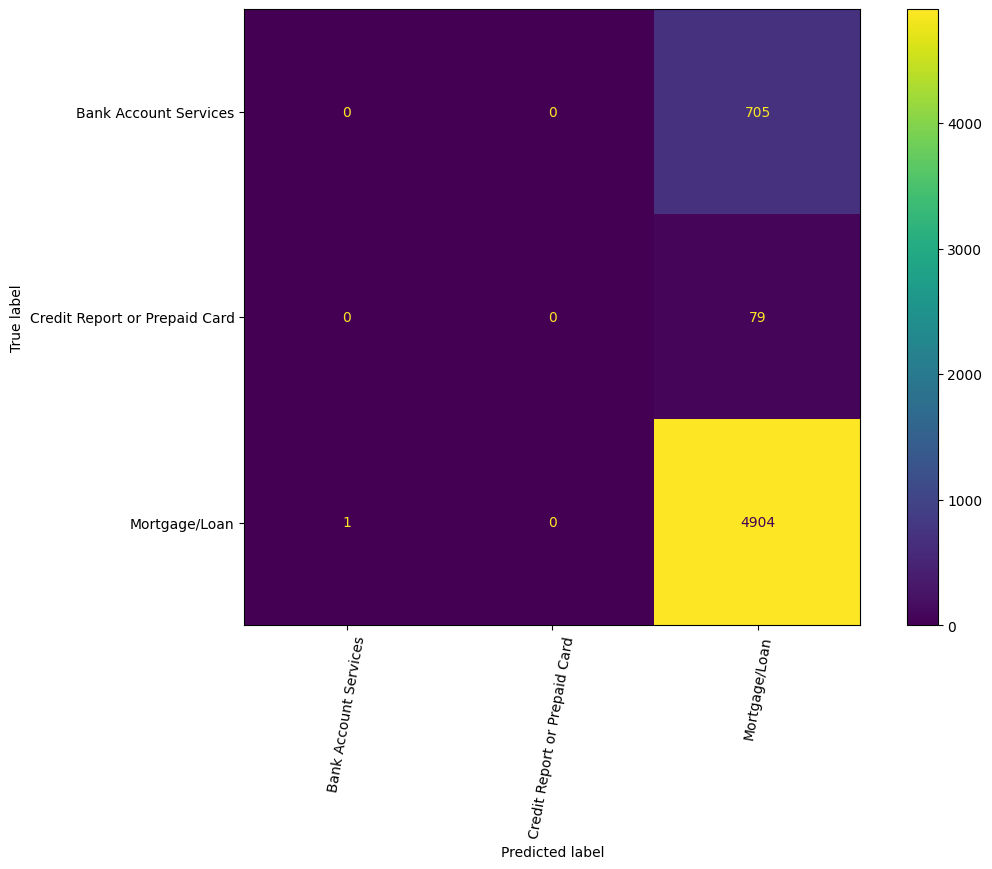

2026/06/28 13:23:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/28 13:23:38 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


[0.61, 0.51, 0.86, 0.86, 0.78, 0.74, 0.86, 0.86, 0.8, 0.8]

In [9]:

mnb = MultinomialNB()
mnb.fit(X_train, y_train)
display_classification_report(model=mnb, 
                              name_model="MultinomialNB", 
                              developer="Maria", 
                              X_train=X_train, 
                              X_test=X_test, 
                              y_train=y_train, 
                              y_test=y_test)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


--- Logging error ---
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/logging/__init__.py", line 1160, in emit
    msg = self.format(record)
          ^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/logging/__init__.py", line 999, in format
    return fmt.format(record)
           ^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/logging/__init__.py", line 703, in format
    record.message = record.getMessage()
                     ^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/logging/__init__.py", line 392, in getMessage
    msg = msg % self.args
          ~~~~^~~~~~~~~~~
TypeError: not all arguments converted during string formatting
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/brian02oriel/Documents/Pyt

Best Score:  0.8639993925950524
Best Hyperparameters:  {'alpha': 1}
------------------- NAME MODEL ------------------- |  MultinomialNBCV


2026/06/28 13:23:45 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Train Accuracy:  0.86
Test Accuracy:  0.86
Classification Report for Train:
               precision    recall  f1-score   support

           0       0.25      0.00      0.00      1653
           1       0.00      0.00      0.00       148
           2       0.86      1.00      0.93     11471

    accuracy                           0.86     13272
   macro avg       0.37      0.33      0.31     13272
weighted avg       0.78      0.86      0.80     13272

Classification Report for Test:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       705
           1       0.00      0.00      0.00        79
           2       0.86      1.00      0.93      4905

    accuracy                           0.86      5689
   macro avg       0.29      0.33      0.31      5689
weighted avg       0.74      0.86      0.80      5689



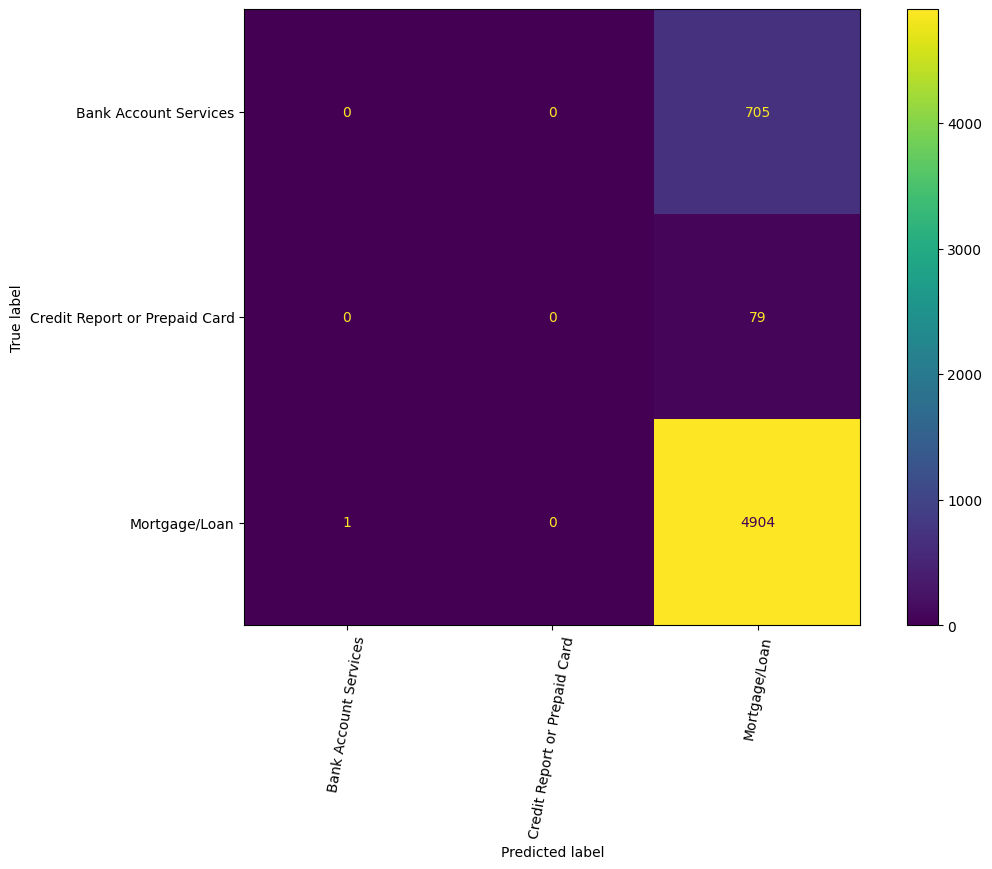

2026/06/28 13:23:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/28 13:23:49 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


[0.61, 0.51, 0.86, 0.86, 0.78, 0.74, 0.86, 0.86, 0.8, 0.8]

In [10]:
folds = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 40)
mnb = MultinomialNB()
mnb_params = {  
'alpha': (1, 0.1, 0.01, 0.001, 0.0001)  
}
grid_search_mnb = grid_search(mnb, folds, mnb_params, scoring="f1_micro")
grid_search_mnb.fit(X_train, y_train)
print_best_score_params(grid_search_mnb)

display_classification_report(model=grid_search_mnb, 
                              name_model="MultinomialNBCV", 
                              developer="Maria", 
                              X_train=X_train, 
                              X_test=X_test, 
                              y_train=y_train, 
                              y_test=y_test, 
                              use_cv= True)

--- Logging error ---
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/logging/__init__.py", line 1160, in emit
    msg = self.format(record)
          ^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/logging/__init__.py", line 999, in format
    return fmt.format(record)
           ^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/logging/__init__.py", line 703, in format
    record.message = record.getMessage()
                     ^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/logging/__init__.py", line 392, in getMessage
    msg = msg % self.args
          ~~~~^~~~~~~~~~~
TypeError: not all arguments converted during string formatting
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/brian02oriel/Documents/Pyt

------------------- NAME MODEL ------------------- |  LogisticRegression


2026/06/28 13:23:53 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Train Accuracy:  0.87
Test Accuracy:  0.86
Classification Report for Train:
               precision    recall  f1-score   support

           0       0.76      0.07      0.13      1653
           1       0.00      0.00      0.00       148
           2       0.87      1.00      0.93     11471

    accuracy                           0.87     13272
   macro avg       0.54      0.36      0.35     13272
weighted avg       0.85      0.87      0.82     13272

Classification Report for Test:
               precision    recall  f1-score   support

           0       0.53      0.04      0.07       705
           1       0.00      0.00      0.00        79
           2       0.87      1.00      0.93      4905

    accuracy                           0.86      5689
   macro avg       0.46      0.34      0.33      5689
weighted avg       0.81      0.86      0.81      5689



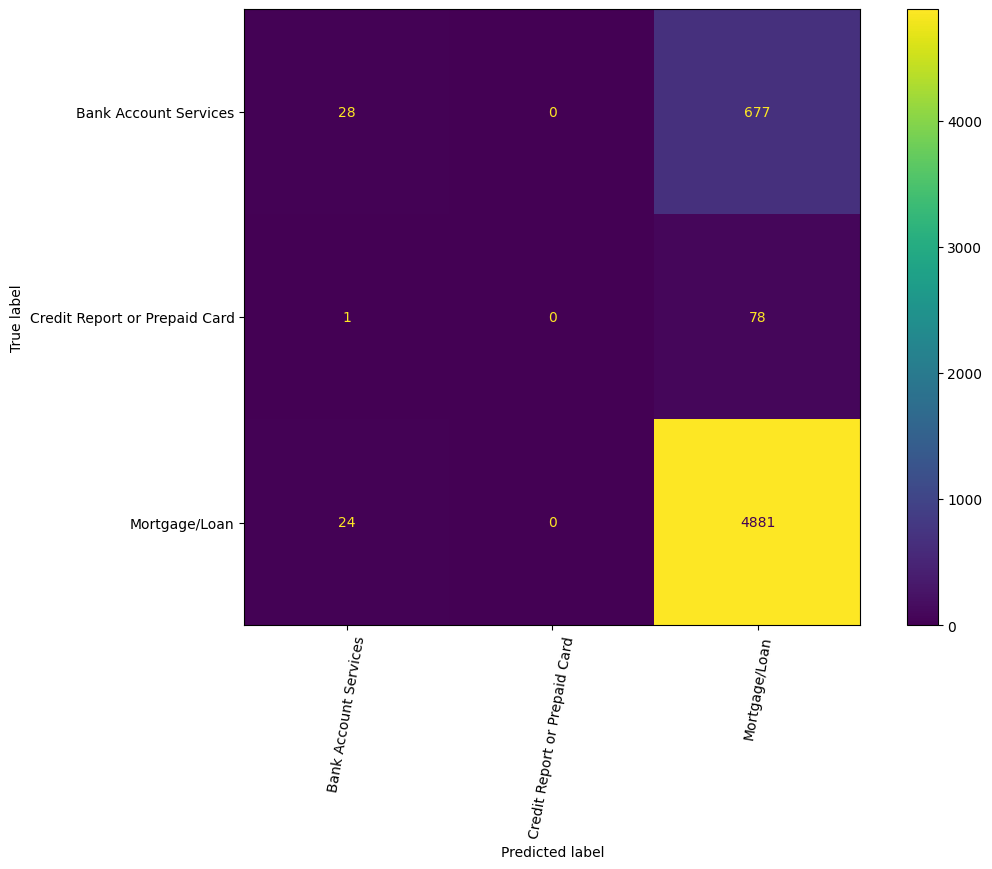

2026/06/28 13:23:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/28 13:23:57 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


[0.86, 0.63, 0.87, 0.86, 0.85, 0.81, 0.87, 0.86, 0.82, 0.81]

In [11]:
log_reg = LogisticRegression(random_state=40)
log_reg.fit(X_train,y_train)
display_classification_report(model=log_reg, 
                              name_model="LogisticRegression", 
                              developer="Maria", 
                              X_train=X_train, 
                              X_test=X_test, 
                              y_train=y_train, 
                              y_test=y_test, 
                              use_cv=False)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


--- Logging error ---
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/logging/__init__.py", line 1160, in emit
    msg = self.format(record)
          ^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/logging/__init__.py", line 999, in format
    return fmt.format(record)
           ^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/logging/__init__.py", line 703, in format
    record.message = record.getMessage()
                     ^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/logging/__init__.py", line 392, in getMessage
    msg = msg % self.args
          ~~~~^~~~~~~~~~~
TypeError: not all arguments converted during string formatting
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/brian02oriel/Documents/Pyt

Best Score:  0.9091911879729457
Best Hyperparameters:  {'C': 10, 'penalty': 'l1', 'solver': 'saga'}
------------------- NAME MODEL ------------------- |  LogisticRegressionCVSmote


2026/06/28 13:28:44 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Train Accuracy:  0.97
Test Accuracy:  0.72
Classification Report for Train:
               precision    recall  f1-score   support

           0       0.93      0.97      0.95     11471
           1       1.00      1.00      1.00     11471
           2       0.97      0.93      0.95     11471

    accuracy                           0.97     34413
   macro avg       0.97      0.97      0.97     34413
weighted avg       0.97      0.97      0.97     34413

Classification Report for Test:
               precision    recall  f1-score   support

           0       0.18      0.30      0.23       705
           1       0.06      0.08      0.07        79
           2       0.88      0.80      0.83      4905

    accuracy                           0.72      5689
   macro avg       0.37      0.39      0.38      5689
weighted avg       0.78      0.72      0.75      5689



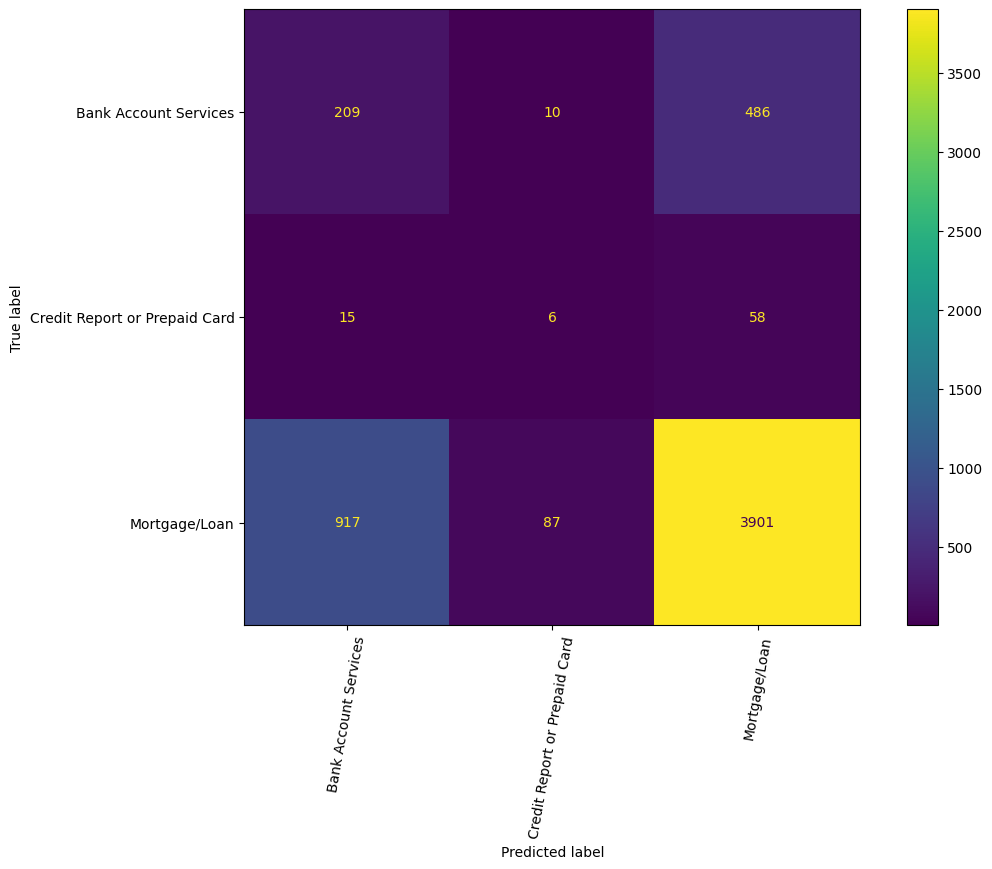

2026/06/28 13:28:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/28 13:28:49 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


[0.99, 0.58, 0.97, 0.72, 0.97, 0.78, 0.97, 0.72, 0.97, 0.75]

In [12]:
# rebalance of the data
smote = SMOTE()
# transform the dataset with the SMOTE algorithm
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
# define the model with the balanced class_weight
log_reg = LogisticRegression(class_weight='balanced')

log_params = {'C': [0.01, 1, 10], 
          'penalty': ['l1', 'l2'],
          'solver': ['liblinear','newton-cg','saga']
         }

grid_search_log = grid_search(log_reg, folds, log_params, scoring="f1_micro")
grid_search_log.fit(X_train_res, y_train_res)  # entrenamiento con los datos rebalanceados

print_best_score_params(grid_search_log)
display_classification_report(grid_search_log,
                              name_model="LogisticRegressionCVSmote", 
                              developer="Maria", 
                              X_train=X_train_res,  # evaluación con los datos rebalanceados
                              X_test=X_test, 
                              y_train=y_train_res,  # etiquetas rebalanceadas
                              y_test=y_test, 
                              use_cv=True)

Fitting 5 folds for each of 512 candidates, totalling 2560 fits


--- Logging error ---
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/logging/__init__.py", line 1160, in emit
    msg = self.format(record)
          ^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/logging/__init__.py", line 999, in format
    return fmt.format(record)
           ^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/logging/__init__.py", line 703, in format
    record.message = record.getMessage()
                     ^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/logging/__init__.py", line 392, in getMessage
    msg = msg % self.args
          ~~~~^~~~~~~~~~~
TypeError: not all arguments converted during string formatting
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/brian02oriel/Documents/Pyt

Best Score:  0.3812581772750344
Best Hyperparameters:  {'criterion': 'gini', 'max_depth': None, 'max_features': None, 'min_samples_leaf': 2, 'splitter': 'random'}
------------------- NAME MODEL ------------------- |  DecisionTreeClassifierCV


2026/06/28 13:30:06 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Train Accuracy:  0.95
Test Accuracy:  0.77
Classification Report for Train:
               precision    recall  f1-score   support

           0       0.76      0.98      0.85      1653
           1       0.62      0.58      0.60       148
           2       1.00      0.95      0.98     11471

    accuracy                           0.95     13272
   macro avg       0.79      0.84      0.81     13272
weighted avg       0.96      0.95      0.96     13272

Classification Report for Test:
               precision    recall  f1-score   support

           0       0.20      0.23      0.22       705
           1       0.02      0.01      0.01        79
           2       0.87      0.86      0.87      4905

    accuracy                           0.77      5689
   macro avg       0.36      0.37      0.37      5689
weighted avg       0.78      0.77      0.77      5689



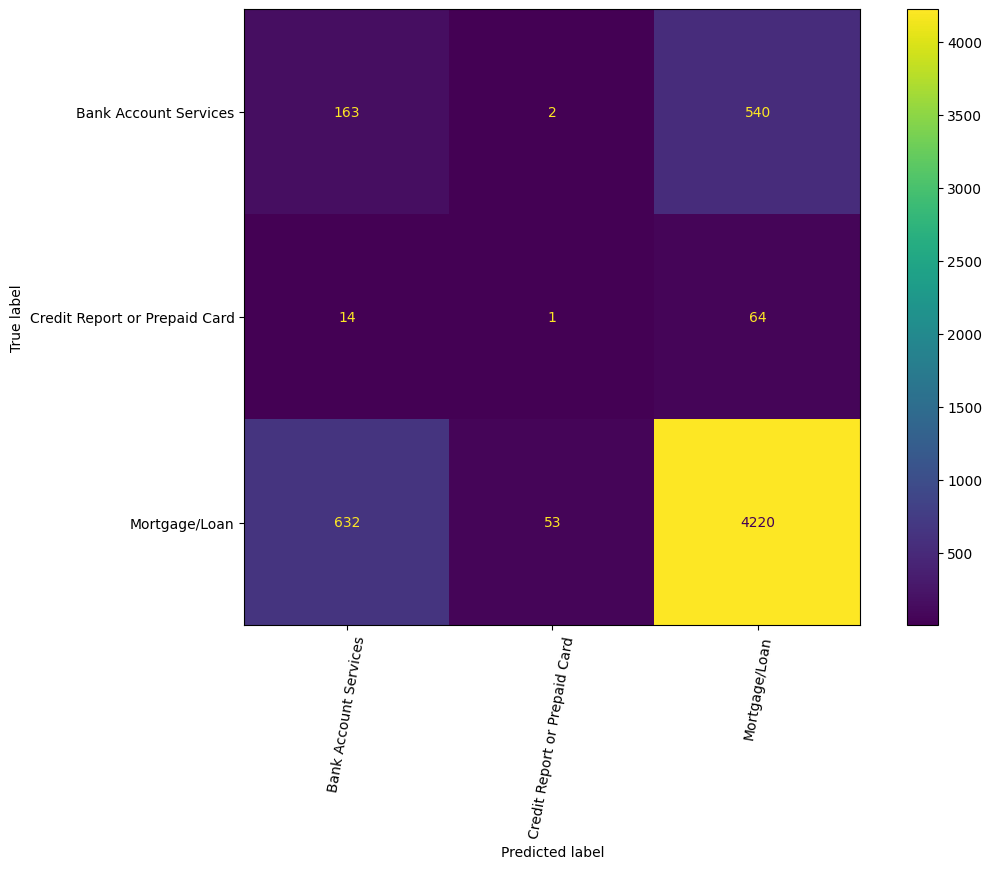

2026/06/28 13:30:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/28 13:30:10 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


[0.99, 0.55, 0.95, 0.77, 0.96, 0.78, 0.95, 0.77, 0.96, 0.77]

In [13]:
dtc_cv = DecisionTreeClassifier(random_state=40)

dtc_params = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': [2,3,4,5,6,7,8,None],
    'min_samples_leaf': [2,3,4,7],
    'max_features': ['auto', 'sqrt', 'log2', None]
}
grid_search_dtc = grid_search(dtc_cv, folds, dtc_params, scoring='f1_macro')
grid_search_dtc.fit(X_train, y_train)
print_best_score_params(grid_search_dtc)
display_classification_report(grid_search_dtc, 
                              name_model="DecisionTreeClassifierCV", 
                              developer="Maria", 
                              X_train=X_train, 
                              X_test=X_test, 
                              y_train=y_train, 
                              y_test=y_test, 
                              use_cv=True)

# Read from Experiment 
Here I check for existing experiments and take one to make predictions

In [14]:
import mlflow

mlflow.set_tracking_uri("sqlite:///mlflow.db")
runs = mlflow.search_runs(experiment_names=["tickets_baseline"])
runs  # a pandas DataFrame with all runs, params, metrics

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.recall_test,metrics.roc_auc_train,metrics.roc_auc_test,metrics.precision_test,...,params.intercept_scaling,params.random_state,params.alpha,params.class_prior,params.fit_prior,params.force_alpha,tags.mlflow.user,tags.mlflow.runName,tags.mlflow.source.type,tags.mlflow.source.name
0,814ff5470bd248f7af3dcdfa136fe265,1,FINISHED,/Users/brian02oriel/Documents/Python projects/...,2026-06-28 18:30:02.361000+00:00,2026-06-28 18:30:10.924000+00:00,0.770610,0.99,0.55,0.779454,...,None,None,None,None,None,None,brian02oriel,DecisionTreeClassifierCV,NOTEBOOK,tracking_data_tickets.ipynb
1,1c542fe607b14a1db9985bfe9951f9c7,1,FINISHED,/Users/brian02oriel/Documents/Python projects/...,2026-06-28 18:28:39.158000+00:00,2026-06-28 18:28:49.786000+00:00,0.723501,0.99,0.58,0.780180,...,None,None,None,None,None,None,brian02oriel,LogisticRegressionCVSmote,NOTEBOOK,tracking_data_tickets.ipynb
2,75c249c236d441e98176ec61ba438902,1,FINISHED,/Users/brian02oriel/Documents/Python projects/...,2026-06-28 18:23:50.172000+00:00,2026-06-28 18:23:57.852000+00:00,0.862893,0.86,0.63,0.812160,...,1,40,None,None,None,None,brian02oriel,LogisticRegression,NOTEBOOK,tracking_data_tickets.ipynb
3,106bc5bf323f482ebaf8a63f865590ab,1,FINISHED,/Users/brian02oriel/Documents/Python projects/...,2026-06-28 18:23:41.893000+00:00,2026-06-28 18:23:49.892000+00:00,0.862014,0.61,0.51,0.743351,...,None,None,1,None,None,None,brian02oriel,MultinomialNBCV,NOTEBOOK,tracking_data_tickets.ipynb
4,c83240a924fb43d2a2149b2c14dd3b81,1,FINISHED,/Users/brian02oriel/Documents/Python projects/...,2026-06-28 18:23:26.062000+00:00,2026-06-28 18:23:38.606000+00:00,0.862014,0.61,0.51,0.743351,...,None,None,1.0,None,True,True,brian02oriel,MultinomialNB,NOTEBOOK,tracking_data_tickets.ipynb
5,2fcf5e82621246798a4ed0fba0c53841,1,FINISHED,/Users/brian02oriel/Documents/Python projects/...,2026-06-20 18:48:52.125000+00:00,2026-06-20 18:49:04.392000+00:00,0.781860,1.00,0.56,0.782927,...,None,None,None,None,None,None,brian02oriel,DecisionTreeClassifierCV,NOTEBOOK,tracking_data_tickets.ipynb
6,0ff3c3d01a95486686aa26796166d787,1,FINISHED,/Users/brian02oriel/Documents/Python projects/...,2026-06-20 18:46:58.861000+00:00,2026-06-20 18:47:12.007000+00:00,0.721568,0.99,0.58,0.778439,...,None,None,None,None,None,None,brian02oriel,LogisticRegressionCVSmote,NOTEBOOK,tracking_data_tickets.ipynb
7,17653c0558454aafa16b238d28b2fd0e,1,FINISHED,/Users/brian02oriel/Documents/Python projects/...,2026-06-20 18:41:35.274000+00:00,2026-06-20 18:41:47.466000+00:00,0.862893,0.86,0.63,0.812160,...,1,40,None,None,None,None,brian02oriel,LogisticRegression,NOTEBOOK,tracking_data_tickets.ipynb
8,aa5f6500de9c4958bba51229fa04399a,1,FINISHED,/Users/brian02oriel/Documents/Python projects/...,2026-06-20 18:41:17.467000+00:00,2026-06-20 18:41:29.584000+00:00,0.862014,0.61,0.51,0.743351,...,None,None,1,None,None,None,brian02oriel,MultinomialNBCV,NOTEBOOK,tracking_data_tickets.ipynb
9,aaa98b3ce7f34fea87cd009f32b4e213,1,FINISHED,/Users/brian02oriel/Documents/Python projects/...,2026-06-20 18:40:55.819000+00:00,2026-06-20 18:41:12.752000+00:00,0.862014,0.61,0.51,0.743351,...,None,None,1.0,None,True,True,brian02oriel,MultinomialNB,NOTEBOOK,tracking_data_tickets.ipynb


In [15]:
runs.columns

Index(['run_id', 'experiment_id', 'status', 'artifact_uri', 'start_time',
       'end_time', 'metrics.recall_test', 'metrics.roc_auc_train',
       'metrics.roc_auc_test', 'metrics.precision_test',
       'metrics.recall_train', 'metrics.precision_train', 'params.developer',
       'params.max_depth', 'params.max_features', 'params.model',
       'params.min_samples_leaf', 'params.splitter', 'params.criterion',
       'params.penalty', 'params.C', 'params.solver', 'params.dual',
       'params.max_iter', 'params.verbose', 'params.n_jobs',
       'params.class_weight', 'params.tol', 'params.l1_ratio',
       'params.fit_intercept', 'params.warm_start', 'params.intercept_scaling',
       'params.random_state', 'params.alpha', 'params.class_prior',
       'params.fit_prior', 'params.force_alpha', 'tags.mlflow.user',
       'tags.mlflow.runName', 'tags.mlflow.source.type',
       'tags.mlflow.source.name'],
      dtype='object')

In [16]:
import mlflow

models = mlflow.search_logged_models(
    experiment_ids=["1"],
    output_format="list",   # gives LoggedModel objects; omit for a DataFrame
)

for m in models:
    print(f"run_id={m.source_run_id}  model_id={m.model_id}  name={m.name}")

run_id=814ff5470bd248f7af3dcdfa136fe265  model_id=m-44bfebe87ee04657b26cd24e4f0c5d92  name=DecisionTreeClassifierCV
run_id=814ff5470bd248f7af3dcdfa136fe265  model_id=m-ac4d2096bebf4aaaa496b41c1e236f57  name=model_DecisionTreeClassifierCV
run_id=1c542fe607b14a1db9985bfe9951f9c7  model_id=m-c500e5359f0d41f2b3cbe3f8b0b17d8f  name=LogisticRegressionCVSmote
run_id=1c542fe607b14a1db9985bfe9951f9c7  model_id=m-f6aeaf22b1654c838a982419955c24ee  name=model_LogisticRegressionCVSmote
run_id=75c249c236d441e98176ec61ba438902  model_id=m-b888005134c343318640e6361c12a7be  name=LogisticRegression
run_id=75c249c236d441e98176ec61ba438902  model_id=m-215820bba75d435bab84c9dbc3a79011  name=model_LogisticRegression
run_id=106bc5bf323f482ebaf8a63f865590ab  model_id=m-f8be1002799f473b983bde39217fdfb2  name=MultinomialNBCV
run_id=106bc5bf323f482ebaf8a63f865590ab  model_id=m-a8359bab8c1b46b693c74e0d6b01edb9  name=model_MultinomialNBCV
run_id=c83240a924fb43d2a2149b2c14dd3b81  model_id=m-e28d714503d443a096763904

In [17]:
# logged_model = 'models:/m-7baa925023404adf88a208a5a8441826'
logged_model = 'runs:/2fcf5e82621246798a4ed0fba0c53841/DecisionTreeClassifierCV'
loaded_model = mlflow.pyfunc.load_model(logged_model)


In [18]:
assert X_train.toarray().shape[0] == y_train.shape[0]

In [19]:
loaded_model

mlflow.pyfunc.loaded_model:
  artifact_path: /home/brian02oriel/Documents/Platzi Courses/ml-courses/TicketClassification/mlruns/1/models/m-7baa925023404adf88a208a5a8441826/artifacts
  flavor: mlflow.sklearn
  run_id: 2fcf5e82621246798a4ed0fba0c53841

In [20]:
dtc_cv_model = mlflow.sklearn.load_model(logged_model)

In [21]:
dtc_cv_model.get_params()

{'cv': StratifiedKFold(n_splits=5, random_state=40, shuffle=True),
 'error_score': nan,
 'estimator__ccp_alpha': 0.0,
 'estimator__class_weight': None,
 'estimator__criterion': 'gini',
 'estimator__max_depth': None,
 'estimator__max_features': None,
 'estimator__max_leaf_nodes': None,
 'estimator__min_impurity_decrease': 0.0,
 'estimator__min_samples_leaf': 1,
 'estimator__min_samples_split': 2,
 'estimator__min_weight_fraction_leaf': 0.0,
 'estimator__monotonic_cst': None,
 'estimator__random_state': 40,
 'estimator__splitter': 'best',
 'estimator': DecisionTreeClassifier(random_state=40),
 'n_jobs': -1,
 'param_grid': {'criterion': ['gini', 'entropy'],
  'splitter': ['best', 'random'],
  'max_depth': [2, 3, 4, 5, 6, 7, 8, None],
  'min_samples_leaf': [2, 3, 4, 7],
  'max_features': ['auto', 'sqrt', 'log2', None]},
 'pre_dispatch': '2*n_jobs',
 'refit': True,
 'return_train_score': False,
 'scoring': 'f1_macro',
 'verbose': 1}

In [23]:
dtc_cv_model.predict(X_test)

array(['2', '2', '0', ..., '2', '2', '2'], shape=(5689,), dtype=object)

In [24]:
from mlflow.tracking import MlflowClient
MLFLOW_TRACKING_URI = "sqlite:///mlflow.db"
client = MlflowClient(tracking_uri=MLFLOW_TRACKING_URI)

In [25]:
runs = mlflow.search_runs()
# Extrae los IDs únicos de los experimentos
experiment_ids = runs['experiment_id'].unique()
experiment_ids

array(['1'], dtype=object)

In [26]:
client.create_experiment("regression_models")

'2'

In [27]:
runs = client.search_runs(experiment_ids=["1"])
for run in runs:
    print(run.info)

<RunInfo: artifact_uri=('/Users/brian02oriel/Documents/Python '
 'projects/platzi-ml-courses/TicketClassification/mlruns/1/814ff5470bd248f7af3dcdfa136fe265/artifacts'), end_time=1782671410924, experiment_id='1', lifecycle_stage='active', run_id='814ff5470bd248f7af3dcdfa136fe265', run_name='DecisionTreeClassifierCV', start_time=1782671402361, status='FINISHED', user_id='brian02oriel'>
<RunInfo: artifact_uri=('/Users/brian02oriel/Documents/Python '
 'projects/platzi-ml-courses/TicketClassification/mlruns/1/1c542fe607b14a1db9985bfe9951f9c7/artifacts'), end_time=1782671329786, experiment_id='1', lifecycle_stage='active', run_id='1c542fe607b14a1db9985bfe9951f9c7', run_name='LogisticRegressionCVSmote', start_time=1782671319158, status='FINISHED', user_id='brian02oriel'>
<RunInfo: artifact_uri=('/Users/brian02oriel/Documents/Python '
 'projects/platzi-ml-courses/TicketClassification/mlruns/1/75c249c236d441e98176ec61ba438902/artifacts'), end_time=1782671037852, experiment_id='1', lifecycle_sta

# Promote a model

In [ ]:
runs= client.search_runs(
    experiment_ids='1',
    filter_string="", #se puede usar un tag en especial o algún parámetro de interés ej: 'tags.model = valor que usaste
    run_view_type=mlflow.entities.ViewType.ACTIVE_ONLY, # Specify to take only ACTIVE runs
    max_results=5,
    order_by=["metrics.precision_test DESC"]

)

In [41]:
for run in runs:
    print(f"run id: {run.info.run_id}, model_name: {run.data.tags['mlflow.runName']}, rmse_valid: {run.data.metrics['precision_test']}")

run id: 75c249c236d441e98176ec61ba438902, model_name: LogisticRegression, rmse_valid: 0.8121599186077411
run id: 17653c0558454aafa16b238d28b2fd0e, model_name: LogisticRegression, rmse_valid: 0.8121599186077411
run id: 2fcf5e82621246798a4ed0fba0c53841, model_name: DecisionTreeClassifierCV, rmse_valid: 0.7829266392529868
run id: 1c542fe607b14a1db9985bfe9951f9c7, model_name: LogisticRegressionCVSmote, rmse_valid: 0.7801795923785313
run id: 814ff5470bd248f7af3dcdfa136fe265, model_name: DecisionTreeClassifierCV, rmse_valid: 0.7794541498887034


In [42]:
run_id = "75c249c236d441e98176ec61ba438902"
model_uri = f"runs:/{run_id}/LogisticRegression"
mlflow.register_model(model_uri, "tickets_classifiers")

Registered model 'tickets_classifiers' already exists. Creating a new version of this model...
2026/06/28 13:54:52 WARNING mlflow.tracking._model_registry.fluent: Run with id 75c249c236d441e98176ec61ba438902 has no artifacts at artifact path 'LogisticRegression', registering model based on models:/m-b888005134c343318640e6361c12a7be instead
Created version '3' of model 'tickets_classifiers'.


<ModelVersion: aliases=[], creation_timestamp=1782672892981, current_stage='None', deployment_job_state=None, description=None, last_updated_timestamp=1782672892981, metrics=None, model_id=None, name='tickets_classifiers', params=None, run_id='75c249c236d441e98176ec61ba438902', run_link=None, source='models:/m-b888005134c343318640e6361c12a7be', status='READY', status_message=None, tags={}, user_id=None, version=3, workspace='default'>

In [43]:
model_name = "tickets_classifiers"
latest_versions = client.get_latest_versions(name=model_name)
for version in latest_versions:
    print(f" version: {version.version} , actual stage: {version._current_stage}")

 version: 3 , actual stage: None


In [44]:
client.transition_model_version_stage(
    name=model_name,
    version=3,
    stage="Staging"
)

<ModelVersion: aliases=[], creation_timestamp=1782672892981, current_stage='Staging', deployment_job_state=None, description=None, last_updated_timestamp=1782672933546, metrics=None, model_id=None, name='tickets_classifiers', params=None, run_id='75c249c236d441e98176ec61ba438902', run_link=None, source='models:/m-b888005134c343318640e6361c12a7be', status='READY', status_message=None, tags={}, user_id=None, version=3, workspace='default'>

In [45]:
client.transition_model_version_stage(
    name=model_name,
    version=2,
    stage="Production"
)

<ModelVersion: aliases=[], creation_timestamp=1782672165155, current_stage='Production', deployment_job_state=None, description='', last_updated_timestamp=1782673366489, metrics=None, model_id=None, name='tickets_classifiers', params=None, run_id='1c542fe607b14a1db9985bfe9951f9c7', run_link='', source='models:/m-c500e5359f0d41f2b3cbe3f8b0b17d8f', status='READY', status_message=None, tags={'model': 'logistic_regression', 'strategy': 'grid_search_cv'}, user_id=None, version=2, workspace='default'>

In [46]:
client.update_model_version(
    name=model_name, 
    version=2,
    description=f"The model version {2} was transitioned to Production on {datetime.today().date()}"
)

<ModelVersion: aliases=[], creation_timestamp=1782672165155, current_stage='Production', deployment_job_state=None, description='The model version 2 was transitioned to Production on 2026-06-28', last_updated_timestamp=1782673436443, metrics=None, model_id=None, name='tickets_classifiers', params=None, run_id='1c542fe607b14a1db9985bfe9951f9c7', run_link='', source='models:/m-c500e5359f0d41f2b3cbe3f8b0b17d8f', status='READY', status_message=None, tags={'model': 'logistic_regression', 'strategy': 'grid_search_cv'}, user_id=None, version=2, workspace='default'>

In [47]:
type(y_test)

pandas.core.series.Series

# Testing the model

In [48]:
import scipy

In [49]:
def testint_model_from_mlflow(model_name: str, stage:str, X_test: scipy.sparse._csr.csr_matrix, Y_test: pd.Series):
    """this function tests a model from mlflow
    Args:
        model_name (str): name of the model
        stage (str): stage of the model
        X_test (scipy.sparse._csr.csr_matrix): test data
        Y_test (scipy.sparse._csr.csr_matrix): test target
    Returns:
        float: rmse of the model
    
    """
    model_uri = f"models:/{model_name}/{stage}"
    model = mlflow.pyfunc.load_model(model_uri)
    y_pred = model.predict(X_test)
    acc_score = round(accuracy_score(Y_test, y_pred), 2)
    return {"rmse": acc_score}

In [50]:
%time
testint_model_from_mlflow(model_name= "tickets_classifiers", stage="Production", X_test=X_test, Y_test=y_test)

CPU times: user 3 μs, sys: 1 μs, total: 4 μs
Wall time: 15 μs


{'rmse': 0.72}

# Ventajas de MLflow:
- __Gestión de Ciclo de Vida:__ Facilita el seguimiento de experimentos, versionado de modelos y reproducción de resultados.
- __Interoperabilidad:__ Es compatible con múltiples frameworks de aprendizaje automático y se integra fácilmente en flujos de trabajo existentes.
- __Abierto y Modular:__ Ofrece una arquitectura modular que permite la flexibilidad y personalización.
- __Trazabilidad y Reproducibilidad:__ Registra métricas, parámetros y artefactos para reproducir modelos y resultados.
- __Comunidad Activa:__ Amplia comunidad de usuarios y contribuciones continuas.

# Desventajas de MLflow:
- __Complejidad para Grandes Volúmenes de Datos:__ Puede enfrentar dificultades al manejar grandes volúmenes de datos o flujos de trabajo muy complejos.
- __Curva de Aprendizaje:__ Requiere tiempo para familiarizarse con todas sus funcionalidades y componentes.
- __Limitaciones en Algunas Funcionalidades:__ Algunas funcionalidades pueden no ser tan avanzadas o flexibles como en otras herramientas especializadas.

# Alternativas a MLflow:__
- __TensorBoard:__ Enfoque específico para TensorFlow, útil para visualizar gráficamente métricas, grafos de modelos y más.
- __DVC (Data Version Control):__ Se enfoca en versionado de datos y modelos, y gestión de experimentos.
- __Comet.ml:__ Ofrece seguimiento de experimentos, colaboración y visualización de manera similar a MLflow.
- __Weights & Biases:__ Ofrece seguimiento de experimentos, colaboración y visualización de manera similar a MLflow.